# 1. Get the data

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tickers = [ # Finance Sector
    'JPM', 'GS', 'MS',
    # Technology Sector
    'AAPL', 'MSFT', 'NVDA', 'AMZN',
    # Energy Sector
    'XOM', 'CVX', 'COP', 'SLB']
data = yf.download(tickers, start="2000-01-01", auto_adjust=False)

print(data.head())
# This script downloads financial data for specified tickers and saves it to a CSV file.
data.to_csv("yfinance_data.csv", index=True)

data.head()

[*********************100%***********************]  11 of 11 completed


Price      Adj Close                                                       \
Ticker          AAPL      AMZN       COP        CVX         GS        JPM   
Date                                                                        
2000-01-03  0.840094  4.468750  7.635040  16.052586  61.663662  23.125723   
2000-01-04  0.769266  4.096875  7.487602  16.052586  57.779671  22.618315   
2000-01-05  0.780523  3.487500  7.350701  16.340528  55.073982  22.478693   
2000-01-06  0.712978  3.278125  7.603444  17.036371  57.430534  22.797825   
2000-01-07  0.746750  3.478125  7.603444  17.336315  57.648754  23.216686   

Price                                                  ...     Volume  \
Ticker             MS       MSFT      NVDA        SLB  ...       AMZN   
Date                                                   ...              
2000-01-03  33.063705  35.668076  0.089425  16.872522  ...  322352000   
2000-01-04  30.614538  34.463207  0.087038  16.642179  ...  349748000   
2000-01-05  29.497

Price      Adj Close                                                       \
Ticker          AAPL      AMZN       COP        CVX         GS        JPM   
Date                                                                        
2000-01-03  0.840094  4.468750  7.635040  16.052586  61.663662  23.125723   
2000-01-04  0.769266  4.096875  7.487602  16.052586  57.779671  22.618315   
2000-01-05  0.780523  3.487500  7.350701  16.340528  55.073982  22.478693   
2000-01-06  0.712978  3.278125  7.603444  17.036371  57.430534  22.797825   
2000-01-07  0.746750  3.478125  7.603444  17.336315  57.648754  23.216686   

Price                                                  ...     Volume  \
Ticker             MS       MSFT      NVDA        SLB  ...       AMZN   
Date                                                   ...              
2000-01-03  33.063705  35.668076  0.089425  16.872522  ...  322352000   
2000-01-04  30.614538  34.463207  0.087038  16.642179  ...  349748000   
2000-01-05  29.497122  34.826580  0.084172  16.603777  ...  769148000   
2000-01-06  30.063471  33.659966  0.078680  17.736294  ...  375040000   
2000-01-07  30.997213  34.099823  0.079994  18.062607  ...  210108000   

Price                                                                          \
Ticker          COP      CVX       GS       JPM       MS      MSFT       NVDA   
Date                                                                            
2000-01-03  1862219  4387600  1822600  12019200  5309000  53228400  300912000   
2000-01-04  1472879  3702400  1647700  11723400  6234400  54119000  300480000   
2000-01-05  4075997  5567600  1516600   8714550  7744200  64059600  188352000   
2000-01-06  2719867  4353400  1845100   8369250  6586000  54976600  120480000   
2000-01-07  1762785  4487400  1127400   6571950  6324800  62013600   71184000   

Price                          
Ticker          SLB       XOM  
Date                           
2000-01-03  7239800  13458200  
2000-01-04  7963000  14510800  
2000-01-05  4826200  17485000  
2000-01-06  8005000  19461600  
2000-01-07  7368600  16603800  

[5 rows x 66 columns]

In [4]:
adj_close = data['Adj Close']
adj_close.columns.name = None  # quita el nombre del nivel 'Ticker'
adj_close = adj_close.reset_index()
adj_close.head()

,Date,AAPL,AMZN,COP,CVX,GS,JPM,MS,MSFT,NVDA,SLB,XOM
0,2000-01-03,0.840094,4.468750,7.635040,16.052586,61.663662,23.125723,33.063705,35.668076,0.089425,16.872522,17.406446
1,2000-01-04,0.769266,4.096875,7.487602,16.052586,57.779671,22.618315,30.614538,34.463207,0.087038,16.642179,17.073048
2,2000-01-05,0.780523,3.487500,7.350701,16.340528,55.073982,22.478693,29.497122,34.826580,0.084172,16.603777,18.003794
3,2000-01-06,0.712978,3.278125,7.603444,17.036371,57.430534,22.797825,30.063471,33.659966,0.078680,17.736294,18.934553
4,2000-01-07,0.746750,3.478125,7.603444,17.336315,57.648754,23.216686,30.997213,34.099823,0.079994,18.062607,18.878984


In [5]:
adj_close.shape

(6454, 12)

# 2. Calculate Daily Returns

In [6]:
daily_returns = adj_close.copy()
daily_returns.iloc[:, 1:] = daily_returns.iloc[:, 1:].pct_change()
daily_returns = daily_returns.dropna()
daily_returns.head()

,Date,AAPL,AMZN,COP,CVX,GS,JPM,MS,MSFT,NVDA,SLB,XOM
1,2000-01-04,-0.084310,-0.083217,-0.019311,0.000000,-0.062987,-0.021941,-0.074074,-0.033780,-0.026700,-0.013652,-0.019154
2,2000-01-05,0.014633,-0.148741,-0.018284,0.017937,-0.046828,-0.006173,-0.036500,0.010544,-0.032922,-0.002308,0.054516
3,2000-01-06,-0.086538,-0.060036,0.034384,0.042584,0.042789,0.014197,0.019200,-0.033498,-0.065253,0.068208,0.051698
4,2000-01-07,0.047369,0.061010,0.000000,0.017606,0.003800,0.018373,0.031059,0.013068,0.016700,0.018398,-0.002935
5,2000-01-10,-0.017588,-0.005391,-0.002769,-0.026990,0.021953,-0.017182,0.035372,0.007292,0.032829,0.009565,-0.013980


In [7]:
daily_returns.shape

(6453, 12)

In [8]:
# max date in daily_returns
daily_returns['Date'].max()

Timestamp('2025-08-29 00:00:00')

In [ ]:
# Select only numeric columns (the tickers)
numeric_returns = daily_returns.select_dtypes(include='number')

# Average daily return per ticker
mean_daily = numeric_returns.mean()

# Approximate annualized return (linear)
mean_annual_linear = mean_daily * 252

# Compound annualized return
mean_annual_compound = (1 + mean_daily) ** 252 - 1

# Combine into a single DataFrame
annual_returns = pd.DataFrame({
    'Linear Annualized': mean_annual_linear,
    'Compound Annualized': mean_annual_compound
})

# Sort by Compound Annualized return descending
annual_returns_sorted = annual_returns.sort_values(by='Compound Annualized', ascending=False)

# Display results
print("=== Annualized Returns Sorted by Compound Return ===")
print(annual_returns_sorted)



=== Annualized Returns Sorted by Compound Return ===
      Linear Annualized  Compound Annualized
NVDA           0.470665             0.600355
AAPL           0.297493             0.346242
AMZN           0.272138             0.312575
JPM            0.168703             0.183702
MS             0.165045             0.179382
GS             0.161292             0.174967
COP            0.155610             0.168314
MSFT           0.148999             0.160621
CVX            0.127886             0.136387
XOM            0.108057             0.114086
SLB            0.104520             0.110154


In [10]:
# Select only numeric columns (the tickers)
numeric_returns = daily_returns.select_dtypes(include='number')

# Daily covariance matrix
daily_cov = numeric_returns.cov()

# Annualized covariance matrix (assuming 252 trading days per year)
annual_cov = daily_cov * 252

annual_corr = numeric_returns.corr()
annual_corr.head(15)

,AAPL,AMZN,COP,CVX,GS,JPM,MS,MSFT,NVDA,SLB,XOM
AAPL,1.000000,0.375998,0.265530,0.276780,0.392555,0.361573,0.373247,0.482306,0.422788,0.262950,0.270690
AMZN,0.375998,1.000000,0.188955,0.204891,0.348878,0.323069,0.346624,0.446292,0.360940,0.195625,0.186547
COP,0.265530,0.188955,1.000000,0.810785,0.424820,0.418063,0.427159,0.314870,0.244107,0.726028,0.779818
CVX,0.276780,0.204891,0.810785,1.000000,0.454493,0.461322,0.471198,0.370708,0.261091,0.718995,0.837946
GS,0.392555,0.348878,0.424820,0.454493,1.000000,0.725872,0.814111,0.472928,0.387841,0.439628,0.423087
JPM,0.361573,0.323069,0.418063,0.461322,0.725872,1.000000,0.684729,0.442509,0.327939,0.438551,0.441397
MS,0.373247,0.346624,0.427159,0.471198,0.814111,0.684729,1.000000,0.472496,0.374189,0.420244,0.442166
MSFT,0.482306,0.446292,0.314870,0.370708,0.472928,0.442509,0.472496,1.000000,0.487480,0.301673,0.351916
NVDA,0.422788,0.360940,0.244107,0.261091,0.387841,0.327939,0.374189,0.487480,1.000000,0.269450,0.239838
SLB,0.262950,0.195625,0.726028,0.718995,0.439628,0.438551,0.420244,0.301673,0.269450,1.000000,0.703100


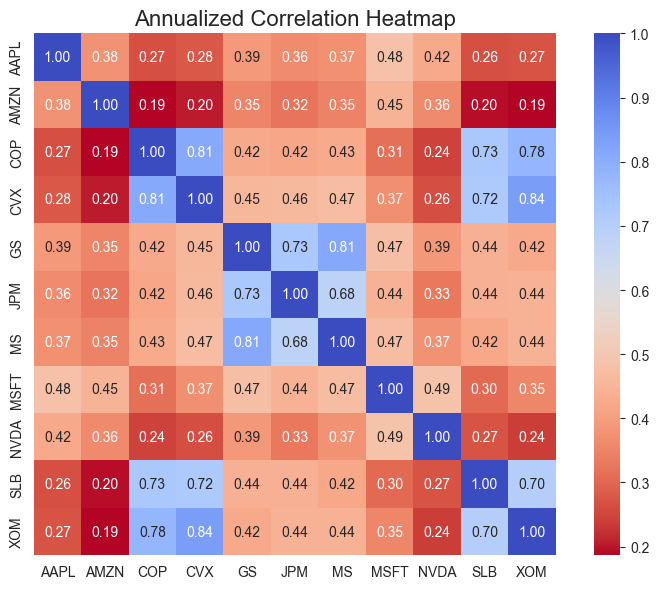

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.figure(figsize=(8,6))
sns.set_style("white")

# Create heatmap
sns.heatmap(annual_corr, 
            annot=True,       
            fmt=".2f",        
            cmap="coolwarm_r",  
            cbar=True,        
            square=True)

plt.title("Annualized Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# 3. Predictive Model

### 3.1. CVX Model

#### 3.1.1. Defining the target and features

In [12]:
#CVX as target
target = daily_returns["CVX"].shift(-1)
target.head()

1    0.017937
2    0.042584
3    0.017606
4   -0.026990
5   -0.009246
Name: CVX, dtype: float64

In [13]:
import pandas as pd

df = daily_returns.copy()

# Moving averages
df["CVX_MA5"] = df["CVX"].rolling(5).mean()
df["CVX_MA10"] = df["CVX"].rolling(10).mean()

# Rolling volatility
df["CVX_volatility"] = df["CVX"].rolling(10).std()

# Momentum / lagged returns
df["CVX_lag1"] = df["CVX"].shift(1)
df["CVX_lag2"] = df["CVX"].shift(2)

# Rolling correlation with XOM
df["CVX_XOM_corr"] = df["CVX"].rolling(20).corr(df["XOM"])


In [14]:
features = ["CVX_MA5", "CVX_MA10", "CVX_volatility", "CVX_lag1", "CVX_lag2", "CVX_XOM_corr"]

# Combine features and target, drop any row with NaN to align
df_cvx = pd.concat([df[features], target.rename("CVX_target")], axis=1).dropna()

X = df_cvx[features]
Y = df_cvx["CVX_target"]




In [15]:
# check
print(df_cvx.head())

     CVX_MA5  CVX_MA10  CVX_volatility  CVX_lag1  CVX_lag2  CVX_XOM_corr  \
20 -0.012293 -0.006969        0.015571  0.012869 -0.020756      0.737426   
21 -0.011811 -0.006105        0.015289 -0.005232  0.012869      0.749514   
22 -0.006851 -0.007045        0.015499 -0.006762 -0.005232      0.754882   
23 -0.009760 -0.011790        0.016218 -0.014372 -0.006762      0.661064   
24 -0.011061 -0.011435        0.016606 -0.035303 -0.014372      0.691442   

    CVX_target  
20   -0.006762  
21   -0.014372  
22   -0.035303  
23    0.006364  
24   -0.009486  


#### 3.1.2. Linearity Validation

Any of the features has a significant linear relationship with the target (R squared = 0.00). We reject the linear regression as a possible predictive model

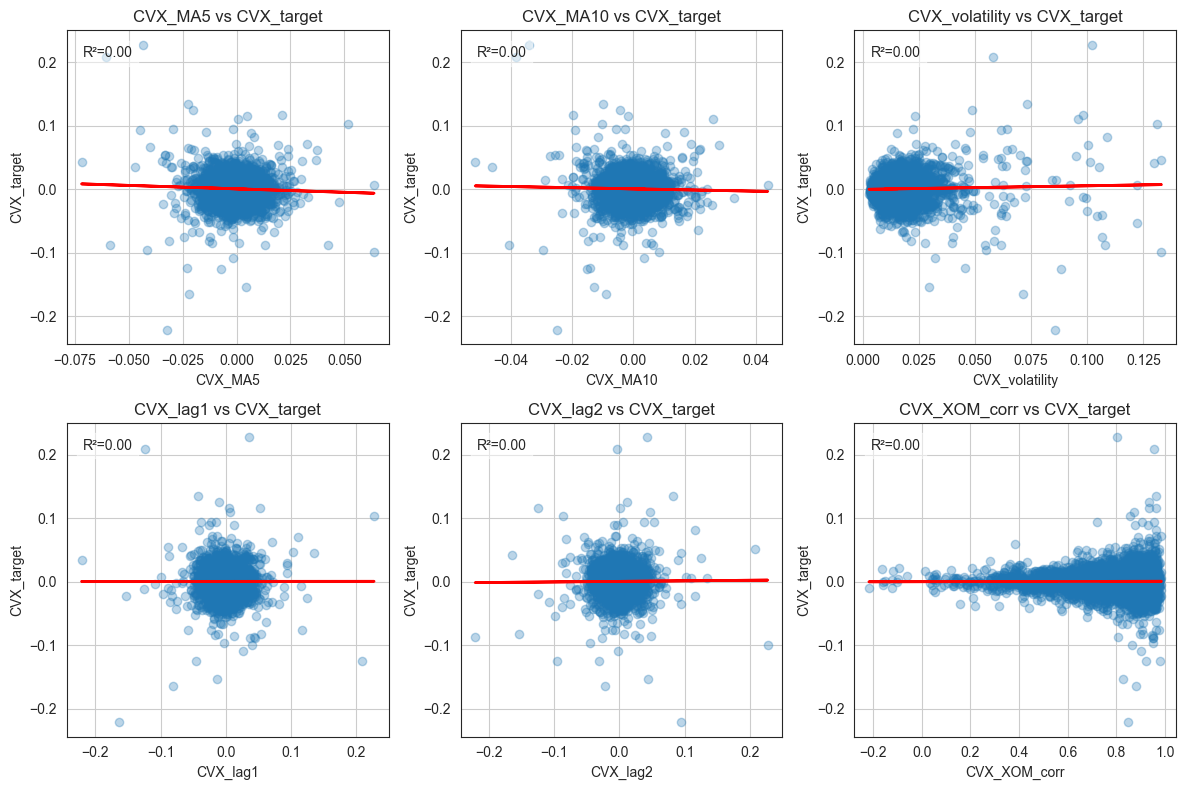

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, f in enumerate(features):
    axes[i].scatter(X[f], Y, alpha=0.3)
    
    # Línea de tendencia
    m, b = np.polyfit(X[f], Y, 1)
    Y_pred = m*X[f] + b
    axes[i].plot(X[f], Y_pred, color='red', linewidth=2)
    
    # R^2
    r2 = r2_score(Y, Y_pred)
    axes[i].text(0.05, 0.95, f'R²={r2:.2f}', transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
    
    axes[i].set_title(f'{f} vs CVX_target')
    axes[i].set_xlabel(f)
    axes[i].set_ylabel('CVX_target')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### 3.1.3. XGBoost

In [17]:
!pip install xgboost



In [18]:
X.head(), Y.head()

(     CVX_MA5  CVX_MA10  CVX_volatility  CVX_lag1  CVX_lag2  CVX_XOM_corr
 20 -0.012293 -0.006969        0.015571  0.012869 -0.020756      0.737426
 21 -0.011811 -0.006105        0.015289 -0.005232  0.012869      0.749514
 22 -0.006851 -0.007045        0.015499 -0.006762 -0.005232      0.754882
 23 -0.009760 -0.011790        0.016218 -0.014372 -0.006762      0.661064
 24 -0.011061 -0.011435        0.016606 -0.035303 -0.014372      0.691442,
 20   -0.006762
 21   -0.014372
 22   -0.035303
 23    0.006364
 24   -0.009486
 Name: CVX_target, dtype: float64)

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Initialize XGBoost regressor
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=2,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.6f}")
print(f"Test R²: {r2:.4f}")

Test MSE: 0.000331
Test R²: -0.1321


          Feature  Importance
5    CVX_XOM_corr    0.226210
0         CVX_MA5    0.192751
2  CVX_volatility    0.169319
1        CVX_MA10    0.156601
3        CVX_lag1    0.145899
4        CVX_lag2    0.109221


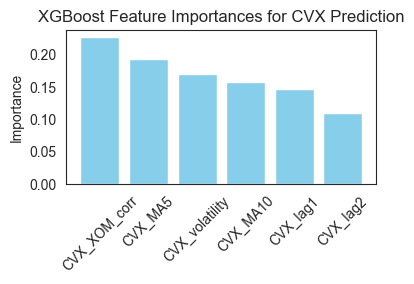

In [20]:
# Get feature importances from the model
importances = model.feature_importances_

# Create a DataFrame for better visualization
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

# Plot feature importances
plt.figure(figsize=(4, 2))
plt.bar(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.title("XGBoost Feature Importances for CVX Prediction")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

3.1.4. Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Split into train and test sets (no shuffle since it's time series)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Initialize Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.6f}")
print(f"Test R²: {r2:.4f}")

# Feature importance
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

Test MSE: 0.000292
Test R²: 0.0016
          Feature  Importance
0         CVX_MA5    0.279513
3        CVX_lag1    0.216921
1        CVX_MA10    0.174388
4        CVX_lag2    0.145701
2  CVX_volatility    0.120623
5    CVX_XOM_corr    0.062853
